[Sascha Spors](https://orcid.org/0000-0001-7225-9992),
Professorship Signal Theory and Digital Signal Processing,
[Institute of Communications Engineering (INT)](https://www.int.uni-rostock.de/),
Faculty of Computer Science and Electrical Engineering (IEF),
[University of Rostock, Germany](https://www.uni-rostock.de/en/)

# Tutorial Signals and Systems (Signal- und Systemtheorie)

Summer Semester 2022 (Bachelor Course #24015)

- lecture: https://github.com/spatialaudio/signals-and-systems-lecture
- tutorial: https://github.com/spatialaudio/signals-and-systems-exercises

Feel free to contact lecturer [frank.schultz@uni-rostock.de](https://orcid.org/0000-0002-3010-0294)

## Übung / Exercise 9

In [1]:
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator
import numpy as np
from scipy import signal
# digital angular frequency vector with 1024 samples
dw = 2*np.pi / 2**10
w = np.arange(0, 2*np.pi, dw)

## Sig Sys UE 7.2 X4(z)

ROC: $|z|>1$
\begin{align}
X_4(z) = \frac{z^2}{z^2+1} = \frac{1}{1+z^{-2}}
\end{align}


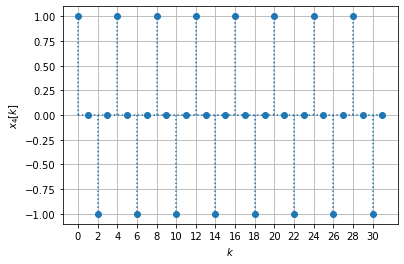

In [2]:
# SigSys 7.2 X4(z) o-0 x4[k], oscillating signal with 2*pi/4
# if interpreted as a system transfer function, this would be semi-stable
# X(z) = z^2 / (z^2+1) = 1 / (1 + z^-2)
# thus b0 = 1, a0 = 1, a1 = 0, a2 = 1
b = [1, 0, 0]  # make sure b and a are of same length,
a = [1, 0, 1]  # since signal.dimpulse relies on that :-(
sys = signal.dlti(b, a, dt=1)  # handle k as integer, i.e. unit time step
ax = plt.subplot(1, 1, 1)
N = 2**5
[k, h] = signal.dimpulse(sys, n=N)
h = np.squeeze(h)
plt.stem(k, h, use_line_collection=True,
         linefmt='C0:', markerfmt='C0o', basefmt='C0:')
ax.xaxis.set_major_locator(MaxNLocator(integer=True))
plt.xticks(np.arange(0, N, 2))
plt.xlabel(r'$k$')
plt.ylabel(r'$x_4[k]$')
plt.grid(True)

## Sig Sys UE 7.2 X6(z)

\begin{align}
X_6(z) = \frac{z^2-z}{z^2-\sqrt{2} z +1} = \frac{1-z^{-1}}{1-\sqrt{2} z^{-1} + z^{-2}}
\end{align}

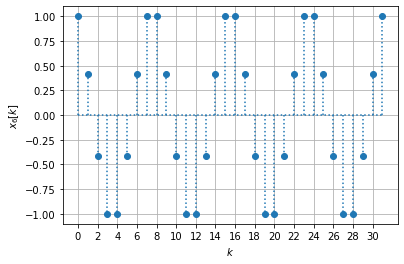

In [3]:
# SigSys 7.2 X6(z) o-0 x6[k], oscillating signal with 2*pi/8
# if interpreted as a system transfer function, this would be semi-stable
# X(z) = z(z-1) / (z^2 - sqrt(2)z +1) = (z^2 - z) / (z^2 - sqrt(2)z +1)
# X(z) = (1 - z^-1) / (1 - sqrt(2)z^-1 + z^-2)
# thus b0 = 1, b1 = -1, a0 = 1, a1 = -sqrt(2), a2 = 1
b = [+1, -1, 0]  # make sure b and a are of same length,
a = [+1, -np.sqrt(2), +1]  # since signal.dimpulse relies on that :-(
sys = signal.dlti(b, a, dt=1)  # handle k as integer, i.e. unit time step
ax = plt.subplot(1, 1, 1)
N = 2**5
[k, h] = signal.dimpulse(sys, n=N)
h = np.squeeze(h)
plt.stem(k, h, use_line_collection=True,
         linefmt='C0:', markerfmt='C0o', basefmt='C0:')
ax.xaxis.set_major_locator(MaxNLocator(integer=True))
plt.xticks(np.arange(0, N, 2))
plt.xlabel(r'$k$')
plt.ylabel(r'$x_6[k]$')
plt.grid(True)

## Sig Sys UE 7.3 System H1

\begin{align}
H_1(z) = \frac{z^3 +z^2 -z + \frac{1}{2}}{z^3} = 1 + z^{-1} - z^{-2} + \frac{1}{2} z^{-3}
\end{align}


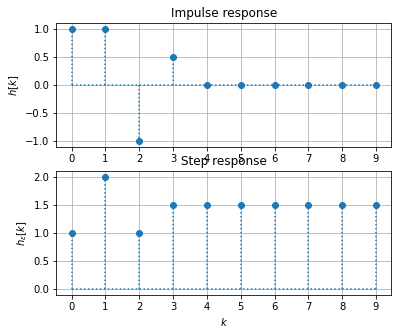

In [4]:
# SigSys 7.3 H1, simple bandpass-like filter
# stable since this is a system with an FIR
# we migth call this a simple FIR filter of order 3 with 3+1 coefficients
b = [1, 1, -1, 1/2]  # make sure b and a are of same length,
a = [1, 0, 0, 0]  # since signal.dimpulse relies on that :-(
# b is identical to the weigthing coefficients of the shifted Diracs in h[k]
# for a: no recursive part, only a0 for weighting y[k]
sys = signal.dlti(b, a, dt=1)  # handle k as integer, i.e. unit time step

N = 10
plt.figure(figsize=(6, 5))
ax = plt.subplot(2, 1, 1)
[k, h] = signal.dimpulse(sys, n=N)
h = np.squeeze(h)
plt.stem(k, h, use_line_collection=True,
         linefmt='C0:', markerfmt='C0o', basefmt='C0:')
ax.xaxis.set_major_locator(MaxNLocator(integer=True))
# plt.xlabel(r'$k$')
plt.ylabel(r'$h[k]$')
plt.title('Impulse response')
plt.grid(True)

ax = plt.subplot(2, 1, 2)
[k, he] = signal.dstep(sys, n=N)
he = np.squeeze(he)
plt.stem(k, he, use_line_collection=True,
         linefmt='C0:', markerfmt='C0o', basefmt='C0:')
ax.xaxis.set_major_locator(MaxNLocator(integer=True))
plt.xlabel(r'$k$')
plt.ylabel(r'$h_\epsilon[k]$')
plt.title('Step response')
plt.grid(True)

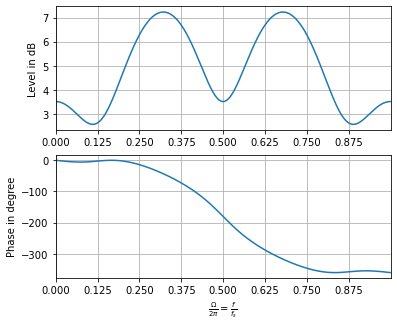

In [5]:
[w, level, phase] = signal.dbode(sys, w=w)

plt.figure(figsize=(6, 5))
ax = plt.subplot(2, 1, 1)
plt.plot(w / 2 / np.pi, level)
plt.xticks(np.arange(0, 1, 0.125))
plt.xlim(0, 1)
#plt.xlabel(r'$\frac{\Omega}{2\pi}= \frac{f}{f_s}$')
plt.ylabel(r'Level in dB')
plt.grid(True)

ax = plt.subplot(2, 1, 2)
plt.plot(w / 2 / np.pi, phase)
plt.xticks(np.arange(0, 1, 0.125))
plt.xlim(0, 1)
plt.xlabel(r'$\frac{\Omega}{2\pi}= \frac{f}{f_s}$')
plt.ylabel(r'Phase in degree')
plt.grid(True)

## Sig Sys UE 7.3 System H2

\begin{align}
H(z) = \frac{z^2}{z^2 - z - 1} = \frac{1}{1 - z^{-1} + z^{-2}}
\end{align}


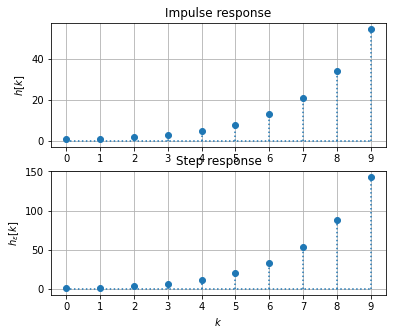

In [6]:
# SigSys 7.3 H2, simple bandstop-like filter, but unstable,
# due to pole outside unit circle!
b = [1, 0, 0]
a = [1, -1, -1]  # recursive part is the bad guy here
sys = signal.dlti(b, a, dt=1)  # handle k as integer, i.e. unit time step

N = 10
plt.figure(figsize=(6, 5))
ax = plt.subplot(2, 1, 1)
[k, h] = signal.dimpulse(sys, n=N)
h = np.squeeze(h)
plt.stem(k, h, use_line_collection=True,
         linefmt='C0:', markerfmt='C0o', basefmt='C0:')
ax.xaxis.set_major_locator(MaxNLocator(integer=True))
# plt.xlabel(r'$k$')
plt.ylabel(r'$h[k]$')
plt.title('Impulse response')
plt.grid(True)

ax = plt.subplot(2, 1, 2)
[k, he] = signal.dstep(sys, n=N)
he = np.squeeze(he)
plt.stem(k, he, use_line_collection=True,
         linefmt='C0:', markerfmt='C0o', basefmt='C0:')
ax.xaxis.set_major_locator(MaxNLocator(integer=True))
plt.xlabel(r'$k$')
plt.ylabel(r'$h_\epsilon[k]$')
plt.title('Step response')
plt.grid(True)

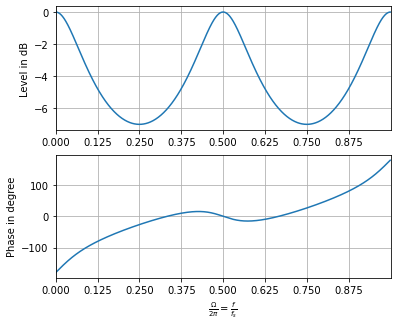

In [7]:
[w, level, phase] = signal.dbode(sys, w=w)

plt.figure(figsize=(6, 5))
ax = plt.subplot(2, 1, 1)
plt.plot(w / 2 / np.pi, level)
plt.xticks(np.arange(0, 1, 0.125))
plt.xlim(0, 1)
#plt.xlabel(r'$\frac{\Omega}{2\pi}= \frac{f}{f_s}$')
plt.ylabel(r'Level in dB')
plt.grid(True)

ax = plt.subplot(2, 1, 2)
plt.plot(w / 2 / np.pi, phase)
plt.xticks(np.arange(0, 1, 0.125))
plt.xlim(0, 1)
plt.xlabel(r'$\frac{\Omega}{2\pi}= \frac{f}{f_s}$')
plt.ylabel(r'Phase in degree')
plt.grid(True)

## Sig Sys UE 7.3 System H3

\begin{align}
H_3(z) = \frac{2 z^2 + 1}{z^2-\frac{1}{2} z} = \frac{2 + z^{-2}}{1-\frac{1}{2} z^{-1}}
\end{align}

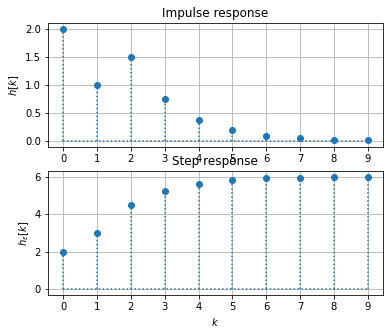

In [8]:
# SigSys 7.3 H3, simple lowpass filter, stable
b = [2, 0, 1]
a = [1, -1/2, 0]
sys = signal.dlti(b, a, dt=1)  # handle k as integer, i.e. unit time step

N = 10
plt.figure(figsize=(6, 5))
ax = plt.subplot(2, 1, 1)
[k, h] = signal.dimpulse(sys, n=N)
h = np.squeeze(h)
plt.stem(k, h, use_line_collection=True,
         linefmt='C0:', markerfmt='C0o', basefmt='C0:')
ax.xaxis.set_major_locator(MaxNLocator(integer=True))
# plt.xlabel(r'$k$')
plt.ylabel(r'$h[k]$')
plt.title('Impulse response')
plt.grid(True)

ax = plt.subplot(2, 1, 2)
[k, he] = signal.dstep(sys, n=N)
he = np.squeeze(he)
plt.stem(k, he, use_line_collection=True,
         linefmt='C0:', markerfmt='C0o', basefmt='C0:')
ax.xaxis.set_major_locator(MaxNLocator(integer=True))
plt.xlabel(r'$k$')
plt.ylabel(r'$h_\epsilon[k]$')
plt.title('Step response')
plt.grid(True)

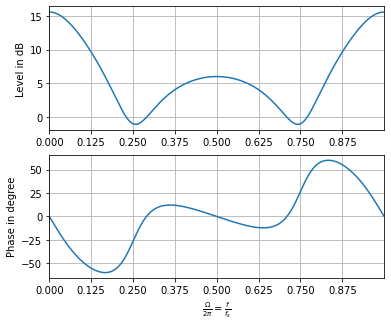

In [9]:
[w, level, phase] = signal.dbode(sys, w=w)

plt.figure(figsize=(6, 5))
ax = plt.subplot(2, 1, 1)
plt.plot(w / 2 / np.pi, level)
plt.xticks(np.arange(0, 1, 0.125))
plt.xlim(0, 1)
#plt.xlabel(r'$\frac{\Omega}{2\pi}= \frac{f}{f_s}$')
plt.ylabel(r'Level in dB')
plt.grid(True)

ax = plt.subplot(2, 1, 2)
plt.plot(w / 2 / np.pi, phase)
plt.xticks(np.arange(0, 1, 0.125))
plt.xlim(0, 1)
plt.xlabel(r'$\frac{\Omega}{2\pi}= \frac{f}{f_s}$')
plt.ylabel(r'Phase in degree')
plt.grid(True)

For the last example, consider that this is an system that was designed (for example to simulate an old-fashioned analog tape recorder frequency repsonse) for $f_s = 44100$ Hz, i.e. the sampling frequency of the old-fashioned CD. What would be the -3dB cutoff-frequency and the maximum damping (smallest dB value) of this very simple lowpass filter.

For that we need to re-plot the graphs with proper numbering / labeling of the physical frequency. Since we know that $\Omega=2\pi \frac{f}{f_s}$, we should rearrange to $f = \frac{\Omega}{2\pi}\cdot f_s$.

Thus:

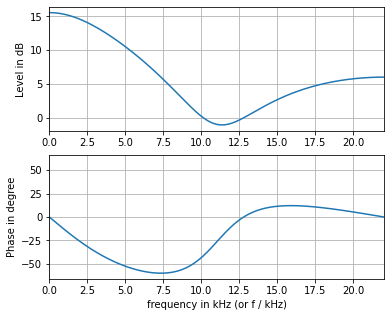

In [10]:
fs = 44100  # sampling frequency in Hz

plt.figure(figsize=(6, 5))
ax = plt.subplot(2, 1, 1)
plt.plot(w / 2 / np.pi * fs / 1000, level)
plt.xlim(0, fs/2/1000)
#plt.xlabel(r'frequency in kHz (or f / kHz)')
plt.ylabel(r'Level in dB')
plt.grid(True)

ax = plt.subplot(2, 1, 2)
plt.plot(w / 2 / np.pi * fs / 1000, phase)
plt.xlim(0, fs/2/1000)
plt.xlabel(r'frequency in kHz (or f / kHz)')
plt.ylabel(r'Phase in degree')
plt.grid(True)

From the plot we might observe that the cut-frequency (-3 dB off to maximum at 0 Hz) is roughly at 3.7 kHz. The minimum magnitude of about -1 dB occurs at ca. 11.4 kHz.

For audio, since our hearing resolution is logarithmic for most of the frequency range, a logarithmic frequency axis is meaningfully used. We know this from Bode plots concept as well. The above plot then is visualized as:

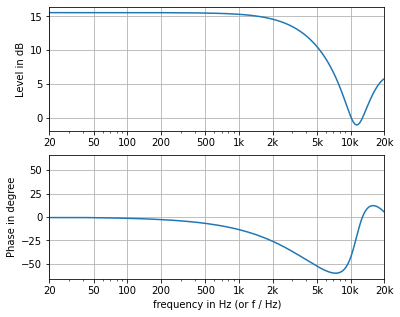

In [11]:
plt.figure(figsize=(6, 5))
ax = plt.subplot(2, 1, 1)
plt.semilogx(w / 2 / np.pi * fs, level)
plt.xlim(20e1, 20e3)
plt.xticks([20, 50, 100, 200, 500, 1000, 2000, 5000, 10000, 20000],
           [20, 50, 100, 200, 500, '1k', '2k', '5k', '10k', '20k'])
#plt.xlabel(r'frequency in Hz (or f / Hz)')
plt.ylabel(r'Level in dB')
plt.grid(True)

ax = plt.subplot(2, 1, 2)
plt.semilogx(w / 2 / np.pi * fs, phase)
plt.xlim(20e1, 20e3)
plt.xticks([20, 50, 100, 200, 500, 1000, 2000, 5000, 10000, 20000],
           [20, 50, 100, 200, 500, '1k', '2k', '5k', '10k', '20k'])
plt.xlabel(r'frequency in Hz (or f / Hz)')
plt.ylabel(r'Phase in degree')
plt.grid(True)

You might elaborate that the two purely imaginary zeros at $\pm \frac{\mathrm{j}}{\sqrt{2}}$ are responsible for the damping at about $f_s / 4=11025$ Hz, i.e. $\Omega=\frac{\pi}{2}$.

## Copyright

This tutorial is provided as Open Educational Resource (OER), to be found at
https://github.com/spatialaudio/signals-and-systems-exercises
accompanying the OER lecture
https://github.com/spatialaudio/signals-and-systems-lecture.
Both are licensed under a) the Creative Commons Attribution 4.0 International
License for text and graphics and b) the MIT License for source code.
Please attribute material from the tutorial as *Frank Schultz,
Continuous- and Discrete-Time Signals and Systems - A Tutorial Featuring
Computational Examples, University of Rostock* with
``github URL, commit number and/or version tag, year, (file name and/or content)``.